# AG-HYPOPT · Trial 22

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-one trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803. Then trial_20 (sw 0.922, h_f 3.899, h_s 3.615, cap 0.203) 0.0821, trial_05 0.0822, trial_09 0.0839, trial_18 0.0844, trial_16 0.0850, trial_21 0.0852, trial_11 0.0859, trial_17 0.0859, trial_06 0.0861, and rising to trial_10 0.0922. All 0 diverged, gamma finite. trial_07 remains the sharp optimum; trials 08-21 have not beaten it. A new observation: trial_20's high-sw (0.922) design prefers a larger cap (~0.20), while trial_07's moderate sw prefers a smaller cap (~0.11), i.e. the cap optimum is coupled to sigma_weight. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_22'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (21/5 trials)
ID |     ei | params
 1 | 2.1450 | {"gamma_rel_cap": 0.16145112812976045, "h_f_scale": 2.69946882850345, "h_s_scale": 3.593487368093636, "sigma_weight": 0.6131555992625067}
 2 | 2.8761 | {"gamma_rel_cap": 0.2776725776807703, "h_f_scale": 3.954653885483253, "h_s_scale": 3.6267004565213767, "sigma_weight": 0.8275855086409682}
 3 | 3.5661 | {"gamma_rel_cap": 0.14350555668422368, "h_f_scale": 3.8843738457965884, "h_s_scale": 3.5973269079713686, "sigma_weight": 0.5121715583946574}
 4 | 3.6331 | {"gamma_rel_cap": 0.1311339058029719, "h_f_scale": 4.0, "h_s_scale": 3.605560474797711, "sigma_weight": 0.7957781824001294}
 5 | 3.5638 | {"gamma_rel_cap": 0.35229514379193666, "h_f_scale": 4.0, "h_s_scale": 3.600377242674837, "sigma_weight": 0.9113491459321991}
 6 | 3.5303 | {"gamma_rel_cap": 0.2325899359690876, "h_f_scale": 4.0, "h_s_scale": 3.64151660840493, "sigma_weight": 1.0}
 7 | 3.8112 | {"gamma_rel_cap": 0.13209357378403458, "h_f_scale": 4.0, "h_s_scale": 3.6191

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

trial_07 (0.0803) is the sharp optimum, trial_20 (0.0821) the next best; the cap optimum is coupled to the sigma weight. The batch is again near-copies; the highest-ei draws that stay in-band are ids 7, 4 and 8.

Candidate 4 (ei 3.6331) keeps the near-optimal kernels (h_f 4.0, h_s 3.606) and a cap (0.131) just above trial_07's, with sigma_weight 0.796 - a small step below trial_07's 0.865. It sits between trial_07's balance and trial_11/15's lower sw, so it gently tests the sigma-weight axis at a cap in the good band; the alternatives move sw further out (id 7, 0.486; id 6, 1.0 with a large cap).

I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # candidate 4: sigma_weight 0.796, h_f_scale 4.0, h_s_scale 3.606, gamma_rel_cap 0.131 (in-region, good cap)


chosen: {'gamma_rel_cap': 0.1311339058029719, 'h_f_scale': 4.0, 'h_s_scale': 3.605560474797711, 'sigma_weight': 0.7957781824001294}
Running  1nW Trans05 ... 

μ 9.39 -> 5.96 | γ 8.5 -> 5.07 | NLL 0.25


Running  1nW Trans20 ... 

μ 17.32 -> 27.71 | γ 8.5 -> 5.42 | NLL 0.64


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.01 | γ 14.1 -> 13.88 | NLL 0.69


Running 3nW Trans100 ... 

μ 175.71 -> 97.35 | γ 14.1 -> 13.82 | NLL 0.66



Total: 7.7 min


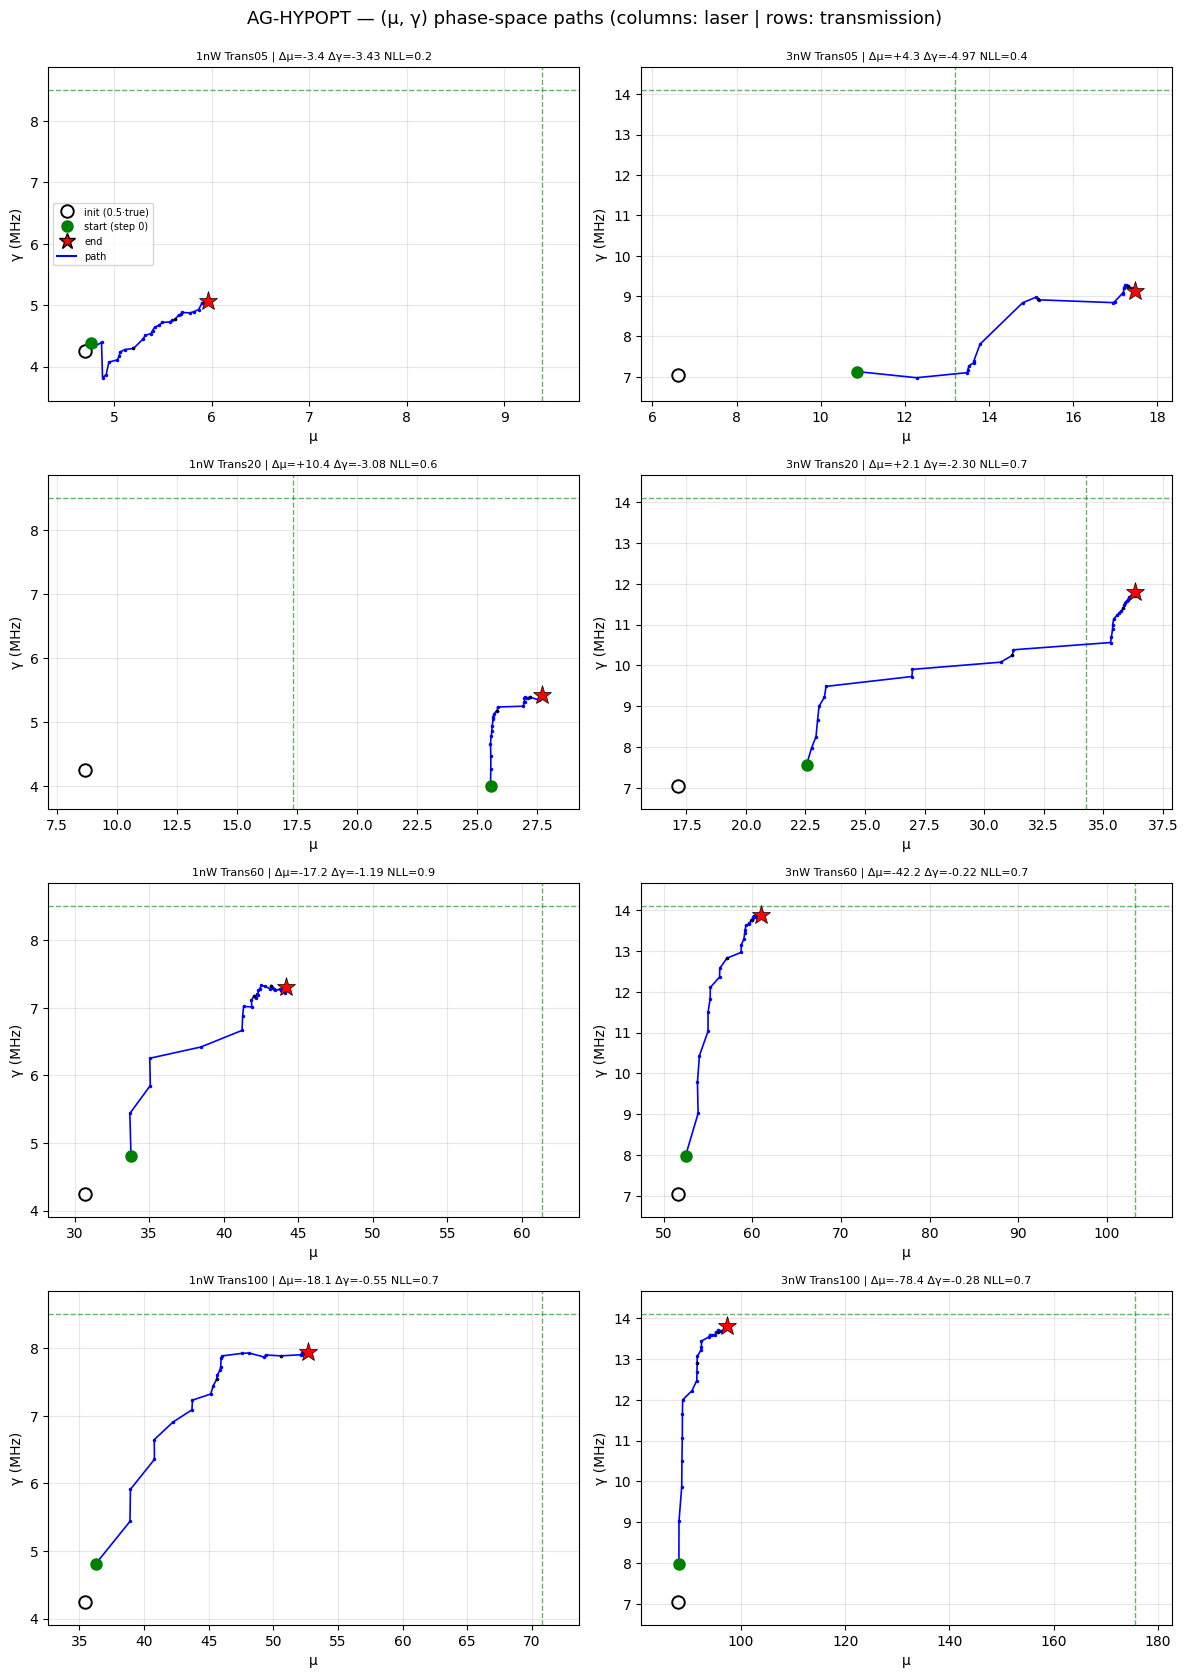

trial finished in 7.8 min
objective = 0.0853 ± 0.0242
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.96   -36.6 |     8.50    5.07   -40.4
1nW Trans20       17.32   27.71   +60.0 |     8.50    5.42   -36.2
1nW Trans60       61.37   44.15   -28.1 |     8.50    7.31   -14.0
1nW Trans100       70.82   52.67   -25.6 |     8.50    7.95    -6.5
3nW Trans05       13.20   17.47   +32.3 |    14.10    9.13   -35.3
3nW Trans20       34.28   36.35    +6.0 |    14.10   11.80   -16.3
3nW Trans60      103.20   61.01   -40.9 |    14.10   13.88    -1.6
3nW Trans100      175.71   97.35   -44.6 |    14.10   13.82    -2.0

weighted objective (T-graded, cap=1.0) = 0.0853 | diverged cells: 0
μ: RMSE 32.956 (rel 37.3%, bias -17.828) | γ: RMSE 2.577 (rel 24.2%, bias -2.004)


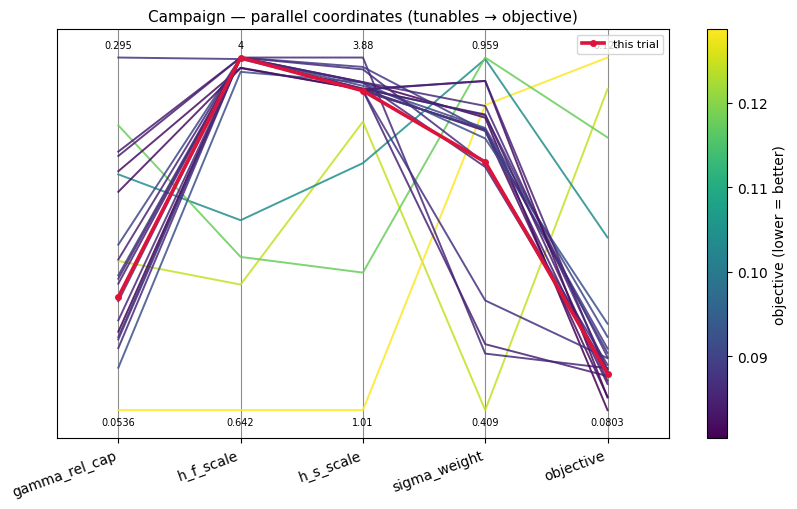

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 22 (sw 0.796, h_f 4.0, h_s 3.606, cap 0.131) ran to completion in 7.8 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0853 +/- 0.0242 - worse than trial_07 (0.0803), between trial_21 (0.0852) and trial_11 (0.0859).

mu rel-RMSE 37.3% (worse than trial_07's 35.9%): same shape - high-T undershoot (3nW Trans100 -44.6%, 3nW Trans60 -40.9%, 1nW Trans60 -28.1%, 1nW Trans100 -25.6%), low-T overshoot (1nW Trans20 +60.0%, 3nW Trans05 +32.3%); bias -17.83.

gamma rel-RMSE 24.2% (worse than trial_07's 22.3%): low T under-estimated (1nW Trans05 -40.4%, 1nW Trans20 -36.2%, 3nW Trans05 -35.3%), high T near truth (-1.6%, -2.0%).

The candidate lowered the sigma weight slightly (0.796 vs 0.865) while keeping the kernels and a cap close to trial_07's; the objective rose again. Every in-region draw since trial_07 has landed in the 0.082-0.092 band, so the campaign is firmly converged on trial_07.

**Summary:** Trial 22 (sw=0.796, h_f=4.0, h_s=3.606, cap=0.131) finished in 7.8 min with 0 diverged cells and gamma finite, objective 0.0853 +/- 0.0242 - worse than trial_07 (mu rel-RMSE 37.3%, gamma rel-RMSE 24.2%).
**Key insight:** Another in-region draw with slightly lower sw (0.796) and a good cap landed at 0.0853, again above trial_07; trials 08-22 confirm the campaign has converged on trial_07.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 22 (sw=0.796, h_f=4.0, h_s=3.606, cap=0.131): objective 0.0853 +/- 0.0242 - worse than trial_07; 0 diverged cells, gamma finite (mu rel-RMSE 37.3%, gamma rel-RMSE 24.2%).'
KEY_INSIGHT = 'Another in-region draw with slightly lower sw (0.796) and a good cap landed at 0.0853, again above trial_07; trials 08-22 confirm the campaign has converged on trial_07.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_22 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_23.ipynb. Open it and follow its cells from the top.
